# Hugo Onghai (hpo8)
## ECE 5242, Project 1
## A) Preparing the Dataset

In [147]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from skimage import color
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

In [148]:
# get necessary image dirs
cwd = Path.cwd()

training_path = (cwd / 'ECE5242Proj1-train').resolve()
cone_path = (cwd / 'cone_masks').resolve()
bkgd_path = (cwd / 'bkgd_masks').resolve()

In [149]:
# I decided to use the HSV and YCbCr color spaces
# HSV separates out Hue, which might be helpful for detecting *orange* cones
# YCbCr separates out Luma (Y), which separates light information from colors (Cb, Cr)
def featurize(full_image_path, mask_path, isCone, num_samples):
    training_name = os.path.basename(file_path)
    training_idx = str(training_name).split('_')[1]
    str_dist_to_cone = str(training_name).split('_')[-1].replace("dist", "").replace(".png", "")
    int_dist_to_cone = int(str_dist_to_cone)

    mask = np.array(Image.open(mask_path).convert("L")) > 128 # threshold with 128 since no is 30 and yes is 215
    ys, xs = np.where(mask) # find all mask true pixels

    # down-sample the full mask to reduce dataset size
    if len(xs) > num_samples:
        rng = np.random.default_rng()
        idx = rng.choice(len(xs), size=num_samples, replace=False)
        ys, xs = ys[idx], xs[idx]

    # I could optimize this to only convert pixels in the ROI
    # but for now, I do the whole image
    rgb = np.array(Image.open(full_image_path).convert("RGB"), dtype=np.uint8)
    rgb_sampled = rgb[ys, xs]
    hsv = color.rgb2hsv(rgb_sampled)
    ycbcr = color.rgb2ycbcr(rgb_sampled)

    H = hsv[:, 0]
    S = hsv[:, 1]
    V = hsv[:, 2]

    Y = ycbcr[:, 0]
    Cb = ycbcr[:, 1]
    Cr = ycbcr[:, 2]

    df = pd.DataFrame({
        "train_idx": np.full(len(xs), int(training_idx)),
        "dist_to_cone": np.full(len(xs), int_dist_to_cone),
        "x": xs,
        "y": ys,
        "isCone": np.ones(len(xs)) if isCone else np.zeros(len(xs)),
        "H": H,
        "S": S,
        "V": V,
        "Y": Y,
        "Cb": Cb, 
        "Cr": Cr
    })

    return df

In [150]:
# first, I featurize all of the pixels in my cone and background masks
image_paths = list(training_path.glob('*.png'))

# which I will write to out_csv, cleaned each run
out_csv = Path("dataset.csv")
out_csv.unlink(missing_ok=True)
write_header = True
num_samples = 10000 # pixels per bkgd mask

for file_path in tqdm(image_paths, desc="Processing masks", unit="img"):
    # get path metadata
    training_name = os.path.basename(file_path)
    training_idx = str(training_name).split('_')[1]
    str_dist_to_cone = str(training_name).split('_')[-1].replace("dist", "").replace(".png", "")
    int_dist_to_cone = int(str_dist_to_cone)
    
    # featurize the cone mask
    cone_name = f"cone_train_{training_idx}_dist{str_dist_to_cone}.png"
    cone_file = cone_path / cone_name
    df = featurize(file_path, cone_file, True, 3*num_samples)
    df.to_csv(out_csv, mode="a", index=False, header=write_header)
    write_header = False
    
    # featurize all three background masks
    for i in range(3):
        bkgd_name = f"bkgd_train_{training_idx}_{i}.png"
        bkgd_file = bkgd_path / bkgd_name
        df = featurize(file_path, bkgd_file, False, num_samples)
        df.to_csv(out_csv, mode="a", index=False, header=False)
    

Processing masks:   0%|          | 0/25 [00:00<?, ?img/s]

## B) Feature Preprocessing (Normalization)

In [151]:
dataset = pd.read_csv("dataset.csv")
y = dataset["isCone"].to_numpy()
X = dataset[["H", "S", "V", "Y", "Cb", "Cr"]]
X_normalized = X.copy()

feature_max = X.abs().max().to_numpy() # save the max values of each feature so that I can normalize my test inputs later
X_normalized = (X / feature_max).to_numpy()

X = X_normalized

## C) Expectation Maximization Implementation

In [152]:
def e_step(x, mus, Sigmas, phis):
    # trying to simplify my matrix shaping, no more image-esque shaping
    
    # get sizes
    K = len(phis)
    n, d = np.shape(x)

    # adjust shapes
    x = x.reshape((1, n, d, 1))
    mus = mus.reshape((K, 1, d, 1))
    Sigmas = Sigmas.reshape((K, 1, d, d))
    
    # compute probabilities
    py = np.tile(phis.reshape((K,1)), (1,n)).reshape([K,n,1,1])
    # print(py.shape, "py")

    # calculate p(x|y)
    dets = np.linalg.det(Sigmas).reshape((K,1,1,1))
    coef = 1.0 / np.sqrt(np.abs((2.0 * np.pi)**d * dets) + 1e-12)
    gaussian = np.exp(-0.5 * (x-mus).transpose([0,1,3,2]) @ np.linalg.inv(Sigmas) @ (x-mus))
    pxy = coef * gaussian

    # calculate p(y|x) and normalize it
    pyx = pxy * py / ((pxy * py).sum(axis=0) + 1e-8)

    y_pred = pyx.argmax(axis=0).reshape(-1, 1)
    pyx = pyx[:, :, 0, 0].T 
    
    return y_pred, pyx # unlike in my first implementation, we need pyx to optimize our predictions, not just the guessed labels.

# y_pred, pyx = e_step(X, mus, Sigmas, phis)
# print(y_pred.shape, pyx.shape)
# print(y.reshape(-1,1).shape)
# print("Training Set Accuracy is: ", (y.reshape(-1, 1) == y_pred).mean())

In [153]:
# helpful resource I used: https://github.com/mr-easy/GMM-EM-Python/blob/master/GMM.py
def m_step(pyx, phis, x):
    # pyx should be n by K and data should be n by d.
    K = len(phis)
    n, d = x.shape
    
    zk = pyx.sum(axis=0)

    # update phis
    phis = zk / n

    # updates mus
    mus = pyx.T @ x
    mus = mus / zk[:, None]

    # update covariances Sigma.shape == (K, d, d)
    Sigmas = np.zeros([K, d, d])
    for i in range(K):
        diff = x - mus[i]
        Sigmas[i] = (diff.T * pyx[:, i]) @ diff
        Sigmas[i] = Sigmas[i] / zk[i]
        Sigmas[i] += 1e-4 * np.eye(d) # add some noice to make sure Sigma[k] stays full rank

    return phis, mus, Sigmas
    
# m_step(pyx, phis, X)

In [154]:
def loglikelihood(x, mus, Sigmas, phis):
    # get sizes
    K = len(phis)
    n, d = np.shape(x)

    # adjust shapes
    x = x.reshape((1, n, d, 1))
    mus = mus.reshape((K, 1, d, 1))
    Sigmas = Sigmas.reshape((K, 1, d, d))
    
    # calculate p(x|k)
    dets = np.linalg.det(Sigmas).reshape((K,1,1,1))
    coef = 1.0 / np.sqrt(np.abs((2.0 * np.pi)**d * dets) + 1e-12)
    gaussian = np.exp(-0.5 * (x-mus).transpose([0,1,3,2]) @ np.linalg.inv(Sigmas) @ (x-mus))
    pxy = coef * gaussian
    pxy = pxy[:, :, 0, 0].T # convert pxy into (n x K)

    # take mean across all K
    px = (pxy * phis.reshape((1, K))).sum(axis=1) # p(x) = sum w_k g_k(x|mu,Sigma class k)
    px = np.maximum(px, 1e-300) # remove true zeros to avoid log issues
    log_likelihood = np.log(px).sum() # now should be one value, the loglikelihood of the current model
    return log_likelihood

## D) GMM Initialization and Training with EM

In [155]:
def init_GMM(n, d, K, X):
    # X is all of the data that all classes should consider
    # in this case, its all the cone data or all the background data that the K gaussians will try to fit
    # parameter shapes with initialized values
    mus = np.zeros([K, d]) # each class must have an average value it takes for each feature
    Sigmas = np.zeros([K, d, d]) # our covariance matrix where Sigmas[i, j] = cov(X_i, X_j) https://cs229.stanford.edu/section/gaussians.pdf
    phis = np.zeros([K]) # the mixing weights
    
    for k in range(K):
        mus[k] = X[np.random.randint(0, X.shape[0])] # initialize randomly on points in the dataset for variance
        Sigmas[k] = np.cov(X.T) + 1e-8 * np.eye(d) # trying to prevent underflow and preserve invertability by adding epsilon to full rank diagonal
        phis[k] = 1.0 / K # switched from X_k.shape[0] / float(n) to ensure phis.sum(along k) == 1

    return mus, Sigmas, phis

In [156]:
# training the GMM using EM
def train_EM(X, mus, Sigmas, phis, threshold = 1e-8, num_iters = 30):
    ll_history = []
    for i in range(num_iters):
        ll = loglikelihood(X, mus, Sigmas, phis)
        print(f"Now on iteration #{i}, current log-likelihood: {ll}")
        ll_history.append(ll)
        _, pyx = e_step(X, mus, Sigmas, phis)
        phis, mus, Sigmas = m_step(pyx, phis, X)
    
        if i > 0: 
            rel_improve = abs(ll - prev_ll) / (abs(prev_ll) + 1e-8)
            if rel_improve < threshold:
                return mus, Sigmas, phis, ll_history
                break
    
        prev_ll = ll

    print("Maximum Iterations Reached!")
    return mus, Sigmas, phis, ll_history

## E) Applying to Data

In [157]:
# split training data into Cone and Background sets
X_tc = X[y == 1]
X_tb = X[y == 0]

# initialize my Cone GMM
n_c, d_c = X_tc.shape
K_c = 2
mus_c, Sigmas_c, phis_c = init_GMM(n_c, d_c, K_c, X_tc)

# initialize my Background GMM
n_b, d_b = X_tb.shape
K_b = 6
mus_b, Sigmas_b, phis_b = init_GMM(n_b, d_b, K_b, X_tb)

In [158]:
# train GMMs with EM
# cone GMM
print("NOW TRAINING CONE GMM!!!!!!!")
mus_c, Sigmas_c, phis_c, ll_history_c = train_EM(X_tc, mus_c, Sigmas_c, phis_c)

# bkgd GMM
print("NOW TRAINING BKGD GMM!!!!!!!")
mus_b, Sigmas_b, phis_b, ll_history_b = train_EM(X_tb, mus_b, Sigmas_b, phis_b)

NOW TRAINING CONE GMM!!!!!!!
Now on iteration #0, current log-likelihood: 436048.0174126803
Now on iteration #1, current log-likelihood: 835344.2606744478
Now on iteration #2, current log-likelihood: 963857.61265937
Now on iteration #3, current log-likelihood: 999132.5190253572
Now on iteration #4, current log-likelihood: 1002728.7846017414
Now on iteration #5, current log-likelihood: 1004001.4670232831
Now on iteration #6, current log-likelihood: 1004607.272195707
Now on iteration #7, current log-likelihood: 1004921.4903192827
Now on iteration #8, current log-likelihood: 1005098.8637499579
Now on iteration #9, current log-likelihood: 1005205.9317416212
Now on iteration #10, current log-likelihood: 1005273.7355513218
Now on iteration #11, current log-likelihood: 1005318.1274172342
Now on iteration #12, current log-likelihood: 1005347.8751039731
Now on iteration #13, current log-likelihood: 1005368.1432260378
Now on iteration #14, current log-likelihood: 1005382.1210886114
Now on iterat

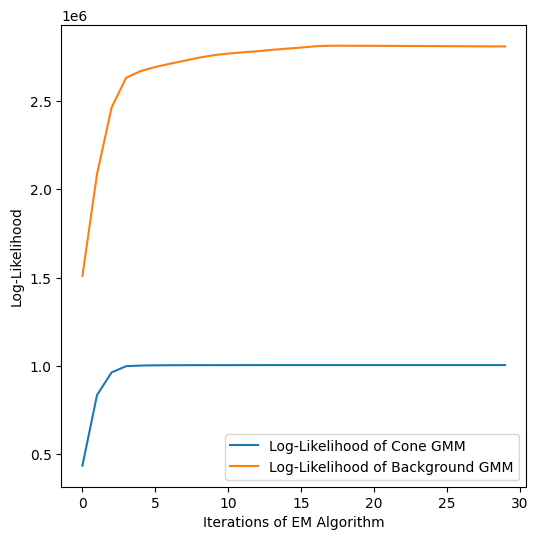

In [159]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(ll_history_c, label="Log-Likelihood of Cone GMM")
ax.plot(ll_history_b, label="Log-Likelihood of Background GMM")

ax.set_xlabel("Iterations of EM Algorithm")
ax.set_ylabel("Log-Likelihood")

ax.legend()

## Step 5. Classify based on GMMs

In [160]:
# inspired by: Prof. Volodymyr Kuleshov's Applied Machine Learning at Cornell Tech textbook
# adapted to preserve pixel-image positioning with a dim=3 matrix instead of feature matrix
def gmm_predictions(x, mus, Sigmas, phis):
    """This returns class assignments and p(y|x) under the GMM.
    
    We compute \arg\max_y p(y|x) as \arg\max_y p(x|y)p(y)

    I tried to allow for two formats to be accepted:
    - image-esque formatting (H by W by 6) where H and W are the height and width of the image in pixels respectively
    - list-esque formatting (H*W by 6) where all of the pixels are listed in line, like a feature/dataset matrix
    """
    H = None
    if x.ndim == 3: # image-esque
        H, W, d = x.shape
        x = x.reshape(-1, d)

    # adjust shapes
    K = len(phis)
    n, d = np.shape(x)
    x = x.reshape((1, n, d, 1))
    mus = mus.reshape((K, 1, d, 1))
    Sigmas = Sigmas.reshape((K, 1, d, d))    
    
    # compute probabilities
    py = np.tile(phis.reshape((K,1)), (1,n)).reshape([K,n,1,1])

    # calculate p(x|y)
    coef = (1.0 / np.sqrt(np.abs((2*np.pi)**d*np.linalg.det(Sigmas))).reshape((K,1,1,1)))
    gaussian = np.exp(-0.5 * (x-mus).transpose([0,1,3,2]) @ np.linalg.inv(Sigmas) @ (x-mus))
    pxy = coef * gaussian

    joint = pxy * py
    px = np.sum(joint, axis=0)+1e-8
    pyx = joint / px
    
    return pyx, px

# y_pred, pyx = gmm_predictions(X.reshape(-1, 1, 6), mus, Sigmas, phis)
# print(y_pred.shape, pyx.shape)
# print(y.reshape(-1,1).shape)
# print("Training Set Accuracy is: ", (y.reshape(-1, 1) == y_pred).mean())

In [161]:
def predict_from_RGB(RGB, mus_c, Sigmas_c, phis_c, n_c, mus_b, Sigmas_b, phis_b, n_b):
    hsv = color.rgb2hsv(RGB)
    ycbcr = color.rgb2ycbcr(RGB)
    threshold = 0.20

    if RGB.ndim == 1:
        n = 1
        x = np.concatenate((hsv, ycbcr))
        x = x / feature_max.reshape(1, 6)

        _, px_c = gmm_predictions(x, mus_c, Sigmas_c, phis_c) # probability of pixel x being seen, given its a cone
        _, px_b = gmm_predictions(x, mus_b, Sigmas_b, phis_b) # probability of pixel x being seen, given its a cone

        prior_c = n_c / (n_b + n_c) # probability of any pixel being a cone
        prior_b = n_b / (n_b + n_c) # probability of any pixel being a cone

        # predict labels, cone is 1/true, background is 0/false.
        return ((px_c * prior_c) > (px_b * prior_b)).astype(int) # use bayes rule to find p(y|x), or at least this value that is proportional to it. higher value gets the label
        
    else:
        xdim, ydim, d = RGB.shape
        x = np.concatenate((hsv, ycbcr), axis=2)
        x = x / feature_max.reshape(1, 1, 6)
        
        _, px_c = gmm_predictions(x, mus_c, Sigmas_c, phis_c) # probability of pixel x being seen, given its a cone
        _, px_b = gmm_predictions(x, mus_b, Sigmas_b, phis_b) # probability of pixel x being seen, given its a cone

        prior_c = n_c / (n_b + n_c) # probability of any pixel being a cone
        prior_b = n_b / (n_b + n_c) # probability of any pixel being a cone

        # predict labels, cone is 1/true, background is 0/false.
        return ((px_c * prior_c) - (px_b * prior_b) > threshold).astype(int).reshape([xdim, ydim]) # use bayes rule to find p(y|x), or at least this value that is proportional to it. higher value gets the label
   
# print(predict_from_RGB(np.zeros([2, 2, 3]), mus, Sigmas, phis))

## Identify Cones and their Distances

In [162]:
CONE_HEIGHT_M = 0.4318 # meters
CONE_DIAM_M = 0.1905 # meters

FOCAL_LENGTH = 710

def estimate_distance_from_bbox(height, width, tol=0.35):
    # height and width should be in units of pixels
    # first determine the ratio of the bbox and decide which dimension to use
    aspect_ratio = height / width
    true_aspect_ratio = CONE_HEIGHT_M / CONE_DIAM_M

    ratio_error = abs(aspect_ratio - true_aspect_ratio) / true_aspect_ratio
    
    if ratio_error < tol: # then likely the full cone is visible
        Z_from_width = CONE_DIAM_M * FOCAL_LENGTH / width
        Z_from_height = CONE_HEIGHT_M * FOCAL_LENGTH / height

        Z_estimate = (Z_from_width + Z_from_height) / 2.0
    elif aspect_ratio > true_aspect_ratio: # then likely the base of the cone is partially obscured, use only height
        Z_estimate = CONE_DIAM_M * FOCAL_LENGTH / width
    else: # then the top or base of the cone is obscured, only use width
        Z_estimate = CONE_HEIGHT_M * FOCAL_LENGTH / height

    return Z_estimate * 100 # convert to cm

In [165]:
import cv2, os
# folder = "ECE5242Proj1-train"
folder = "Proj1TestImages"

testing_files = (cwd / folder).resolve().glob('*.png')

for filename in testing_files:
    path = os.path.join(folder, filename)
    imageName = os.path.basename(filename)
    
    # read one test image
    img = cv2.imread(path)

    if img is None:
        print("Skipping: ", path)
        continue
    
    img2 = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # fig, ax = plt.subplots(1, 2, figsize=(8,6))
    # plt.suptitle(imageName)
    for axis in ax.ravel():
        axis.set_axis_off()

    # ax[0].imshow(img2)
    # ax[0].set_title("Original")

    pred_mask = predict_from_RGB(img2, mus_c, Sigmas_c, phis_c, n_c, mus_b, Sigmas_b, phis_b, n_b)
    # ax[1].imshow(pred_mask)
    # ax[1].set_title("Predicted Mask")

    # following project guidelines and label image regions example with coins on scikit-image
    # https://scikit-image.org/docs/dev/auto_examples/segmentation/plot_label.html
    from skimage.measure import label, regionprops 
    from skimage.color import label2rgb
    import matplotlib.patches as mpatches
    
    label_pm = label(pred_mask, connectivity=pred_mask.ndim)
    label_pm_overlay = label2rgb(label_pm, image=pred_mask, bg_label=0)
    
    # ax[1].imshow(label_pm_overlay)

    num_cones_detected = 0
    
    props = regionprops(label_pm)
    for region in sorted(
        props,
        key = lambda r: r.area,
        reverse = True
    ): # sorting regions by decreasing size (source: https://stackoverflow.com/questions/63974593/how-to-order-the-regions-in-regionprops-by-area)
        # take regions with large enough areas
        minr, minc, maxr, maxc = region.bbox
        height = maxr-minr
        width = maxc-minc

        if num_cones_detected >= 2:
            break
        
        if region.area >= 200 and height > width: # assuming now that the cone should be shown taller than it is wide, but could fail is cone is sideways or more than halfway obscured in height
            num_cones_detected += 1
            
            # rect = mpatches.Rectangle(
            #     (minc, minr),
            #     width,
            #     height,
            #     fill = False,
            #     edgecolor = 'red',
            #     linewidth = 2
            # )
            # ax[1].add_patch(rect)

            Z_estimate = estimate_distance_from_bbox(height, width)
            print(f"ImageName: {imageName}, Down: {minc}, Right: {minr}, Distance: {Z_estimate} cm")

            # plt.text(
            #     x = minc,
            #     y = maxr + 15,
            #     s = f"{Z_estimate:.1f} cm",
            #     color = "yellow",
            #     fontsize = 12,
            #     weight = "bold"
            # )

    # out_path = os.path.join("./GMM_results", imageName)
    # plt.savefig(out_path, dpi=300, bbox_inches="tight")
    # plt.show()
            

ImageName: test_1.png, Down: 208, Right: 342, Distance: 346.80769230769226 cm
ImageName: test_2.png, Down: 412, Right: 305, Distance: 121.96334069535482 cm
ImageName: test_3.png, Down: 283, Right: 335, Distance: 216.3677455357143 cm
ImageName: test_3.png, Down: 471, Right: 239, Distance: 1179.146153846154 cm
ImageName: test_4.png, Down: 246, Right: 151, Distance: 988.9612903225807 cm
ImageName: test_4.png, Down: 291, Right: 374, Distance: 716.3505555555556 cm
ImageName: test_5.png, Down: 273, Right: 303, Distance: 99.74461888782359 cm
ImageName: test_5.png, Down: 237, Right: 324, Distance: 255.01203124999998 cm
ImageName: train_1_dist915.png, Down: 306, Right: 400, Distance: 962.0816964285716 cm
ImageName: train_1_dist915.png, Down: 165, Right: 400, Distance: 1014.6921836228287 cm
ImageName: train_6_dist305.png, Down: 39, Right: 427, Distance: 163.94545454545457 cm
ImageName: train_6_dist305.png, Down: 132, Right: 677, Distance: 249.25040650406504 cm
ImageName: train_2_dist305.png, Dow